In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# defining the function for the ODE
def f(t, T):
    return -k * (T - T_room)

# setting the parameters
k = 0.3
T_room = 20
h = 0.1
t_end = 10

# creating the time steps for the simulation
t = np.arange(0, t_end + h, h)

# initializing and array with the same length as t to store the temperature values
T = np.zeros(len(t))

# setting the initial condition and calculating the first step using Euler's method
T[0] = 100
T[1] = T[0] + h * f(t[0], T[0])


# checking wheter it follows the expected decaying behavior
print(f"T0 = {T[0]:.4f}")
print(f"T1 = {T[1]:.4f}")

T0 = 100.0000
T1 = 97.6000


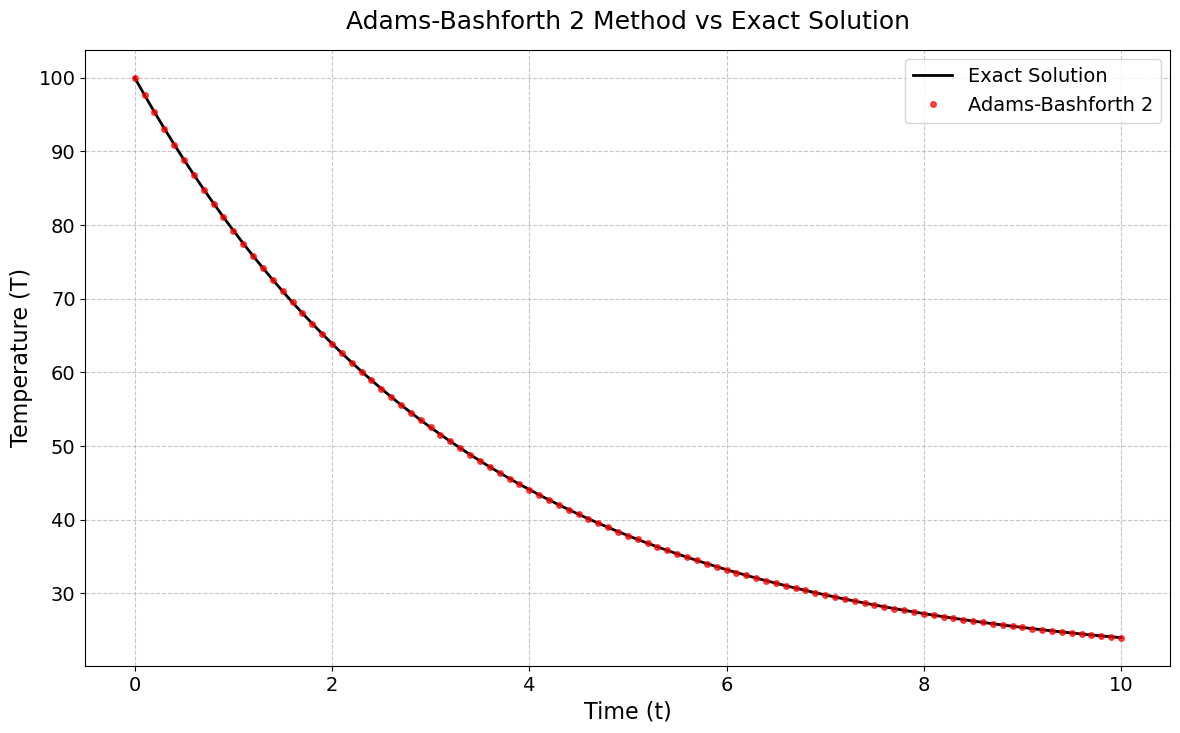

In [23]:
# Adams-Bashforth 2 method

def solve_ab2(h):

    t = np.arange(0, 10 + h, h)
    T = np.zeros(len(t))
    
    T[0] = 100
    
    # first step predicted using explicit Euler method
    T[1] = T[0] + h * f(t[0], T[0])
    
    # AB2 loop
    for n in range(1, len(t) - 1):
        f_n = f(t[n], T[n])
        f_nm1 = f(t[n - 1], T[n - 1])
        T[n + 1] = T[n] + h / 2 * (3 * f_n - f_nm1)
    
    T_exact = 20 + 80 * np.exp(-0.3 * t) # calculating the exact solution for comparison
    error = np.abs(T - T_exact) # calculating the absolute error at each time step
    
    max_error = np.max(error)
    
    return t, T, T_exact, max_error

t, T, T_exact, max_error = solve_ab2(0.1)

# plotting the results
plt.figure(figsize=(14, 8))
plt.plot(t, T_exact, label='Exact Solution', linestyle='-', color='black', lw=2)
plt.plot(t, T, label='Adams-Bashforth 2', ls = " ",marker='o', ms=4, color='red', alpha=0.7)
plt.title('Adams-Bashforth 2 Method vs Exact Solution', fontsize=18, pad=15)
plt.xlabel('Time (t)', fontsize=16)
plt.ylabel('Temperature (T)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

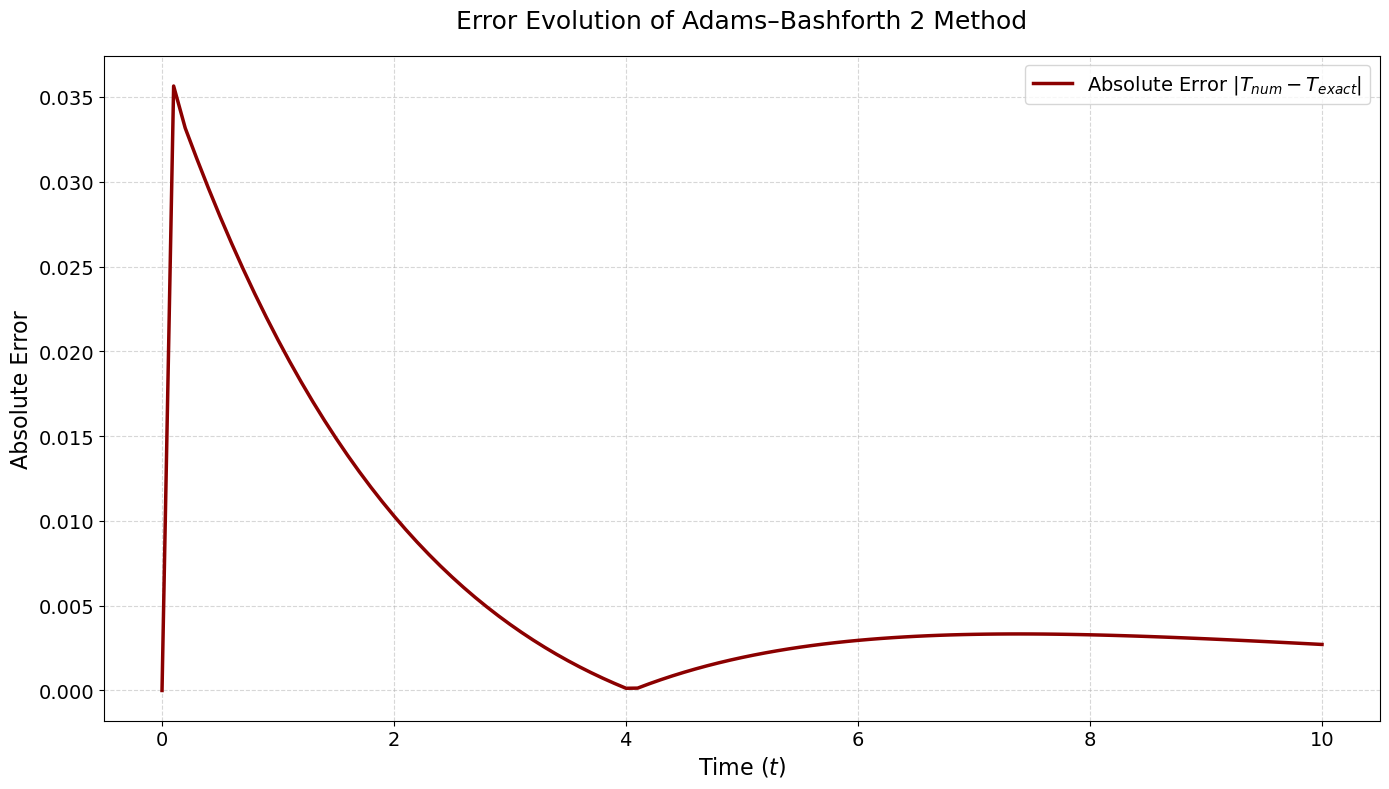

In [24]:
# plotting the error evolution
error = np.abs(T - T_exact)

plt.figure(figsize=(14, 8))
plt.plot(t, error, label="Absolute Error $|T_{num} - T_{exact}|$", color='darkred', linewidth=2.5)

plt.title("Error Evolution of Adams–Bashforth 2 Method", fontsize=18, pad=20)
plt.xlabel("Time ($t$)", fontsize=16)
plt.ylabel("Absolute Error", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()

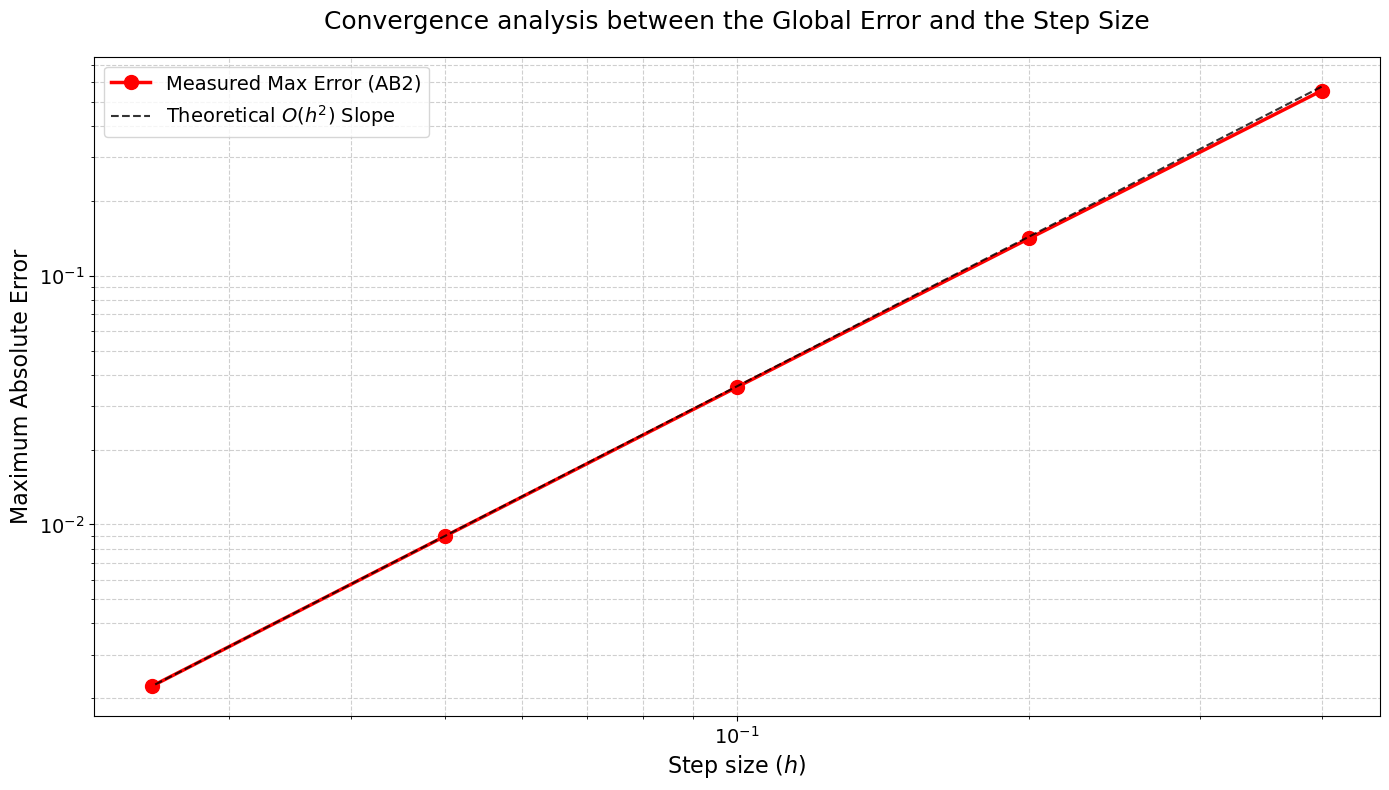

In [25]:
# the step sizes for testing the convergence
hs = [0.4, 0.2, 0.1, 0.05, 0.025]
errors = []

for h in hs:
    t, T_ab2, T_exact, max_err = solve_ab2(h)
    errors.append(max_err)

plt.figure(figsize=(14, 8))

# plotting the measured errors for each step size on a log-log scale
plt.loglog(hs, errors, marker='o', markersize=10, linewidth=2.5, 
           color='red', label='Measured Max Error (AB2)')

# add a theoretical O(h^2) reference line for comparison
# we used the last error and step size to scale the reference line appropriately
h_ref = np.array(hs)
error_ref = (errors[-1] / hs[-1]**2) * h_ref**2
plt.loglog(h_ref, error_ref, linestyle='--', color='black', alpha=0.8, 
           label='Theoretical $O(h^2)$ Slope')

plt.title("Convergence analysis between the Global Error and the Step Size", fontsize=18, pad=20)
plt.xlabel("Step size ($h$)", fontsize=16)
plt.ylabel("Maximum Absolute Error", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

In [26]:
# to perform a direct comparison between the Euler method and the AB2 method, we can implement the Euler method in a similar way and then compare the results.
def solve_euler(h):
    t = np.arange(0, 10 + h, h)
    T = np.zeros(len(t))
    
    T[0] = 100
    
    for n in range(len(t) - 1):
        T[n + 1] = T[n] + h * f(t[n], T[n])
    
    T_exact = 20 + 80 * np.exp(-0.3 * t)
    error = np.max(np.abs(T - T_exact))
    
    return t, T, T_exact, error


h = 0.1

t, T_euler, T_exact, err_euler = solve_euler(h)
_, T_ab2, _, err_ab2 = solve_ab2(h)



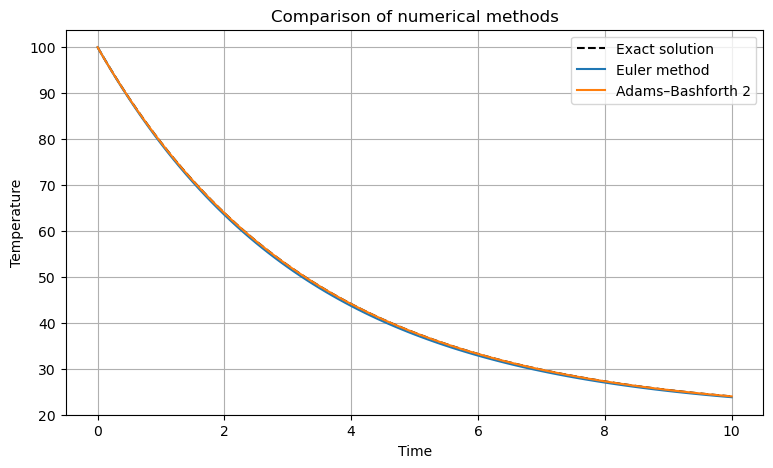

In [27]:
# by plotting the results together no significant difference can be observed.
plt.figure(figsize=(9,5))

plt.plot(t, T_exact, 'k--', label="Exact solution")
plt.plot(t, T_euler, label="Euler method")
plt.plot(t, T_ab2, label="Adams–Bashforth 2")

plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Comparison of numerical methods")
plt.grid(True)
plt.legend()
plt.show()

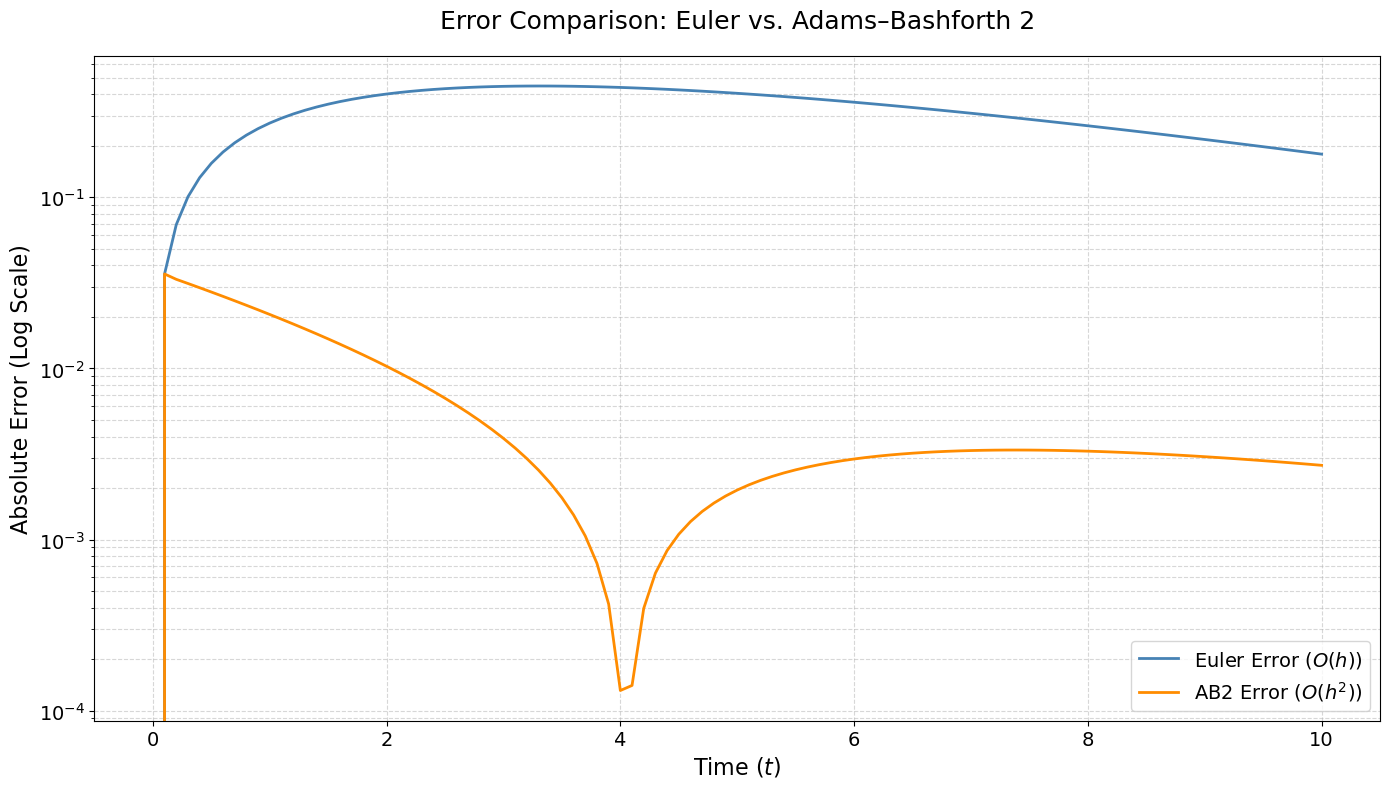

In [ ]:
# compute the absolute errors for both methods
error_euler = np.abs(T_euler - T_exact)
error_ab2 = np.abs(T_ab2 - T_exact)

plt.figure(figsize=(14, 8))

# plotting the errors on a log scale to better visualize the differences in magnitude
plt.plot(t, error_euler, label="Euler Error ($O(h)$)", linewidth=2, color='steelblue')
plt.plot(t, error_ab2, label="AB2 Error ($O(h^2)$)", linewidth=2, color='darkorange')

plt.xlabel("Time ($t$)", fontsize=16)
plt.ylabel("Absolute Error (Log Scale)", fontsize=16)
plt.title("Error Comparison: Euler vs. Adams–Bashforth 2", fontsize=18, pad=20)

plt.yscale("log") # using a log scale to visualize the magnitude of difference
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

In [29]:
def solve_am2(h, tol=1e-10, max_iter=20):
    t = np.arange(0, 10 + h, h)
    N = len(t)

    T = np.zeros(N)
    T[0] = 100

    # initial step using Euler's method
    T[1] = T[0] + h * f(t[0], T[0])

    for n in range(1, N - 1):

        # initial guess (explicit Euler predictor) at every step
        y_guess = T[n] + h * f(t[n], T[n])

        for _ in range(max_iter):
            f_np1 = f(t[n+1], y_guess)
            
            y_new = T[n] + (h/12) * (5*f_np1 + 8*f(t[n], T[n]) - f(t[n-1], T[n-1]))

            if abs(y_new - y_guess) < tol: # cheking for convergence
                break

            y_guess = y_new

        T[n+1] = y_new

    T_exact = 20 + 80 * np.exp(-0.3 * t)
    error = np.max(np.abs(T - T_exact))

    return t, T, T_exact, error

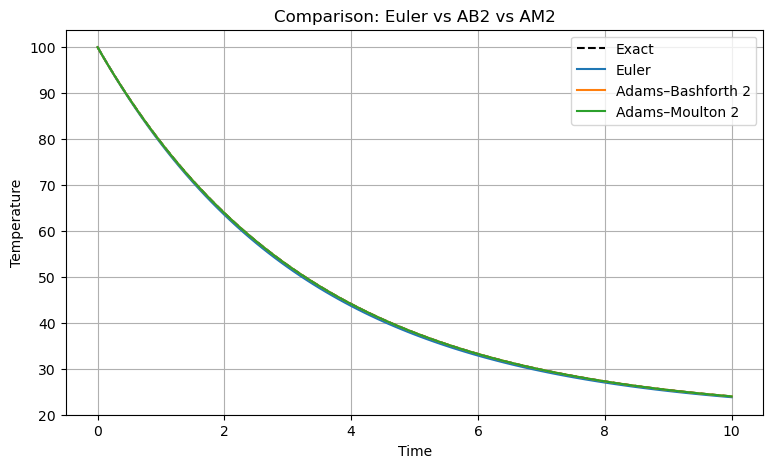

In [30]:
plt.figure(figsize=(9,5))

plt.plot(t, T_exact, 'k--', label="Exact")
plt.plot(t, T_euler, label="Euler")
plt.plot(t, T_ab2, label="Adams–Bashforth 2")
plt.plot(t, T_am2, label="Adams–Moulton 2")

plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Comparison: Euler vs AB2 vs AM2")
plt.grid(True)
plt.legend()
plt.show()

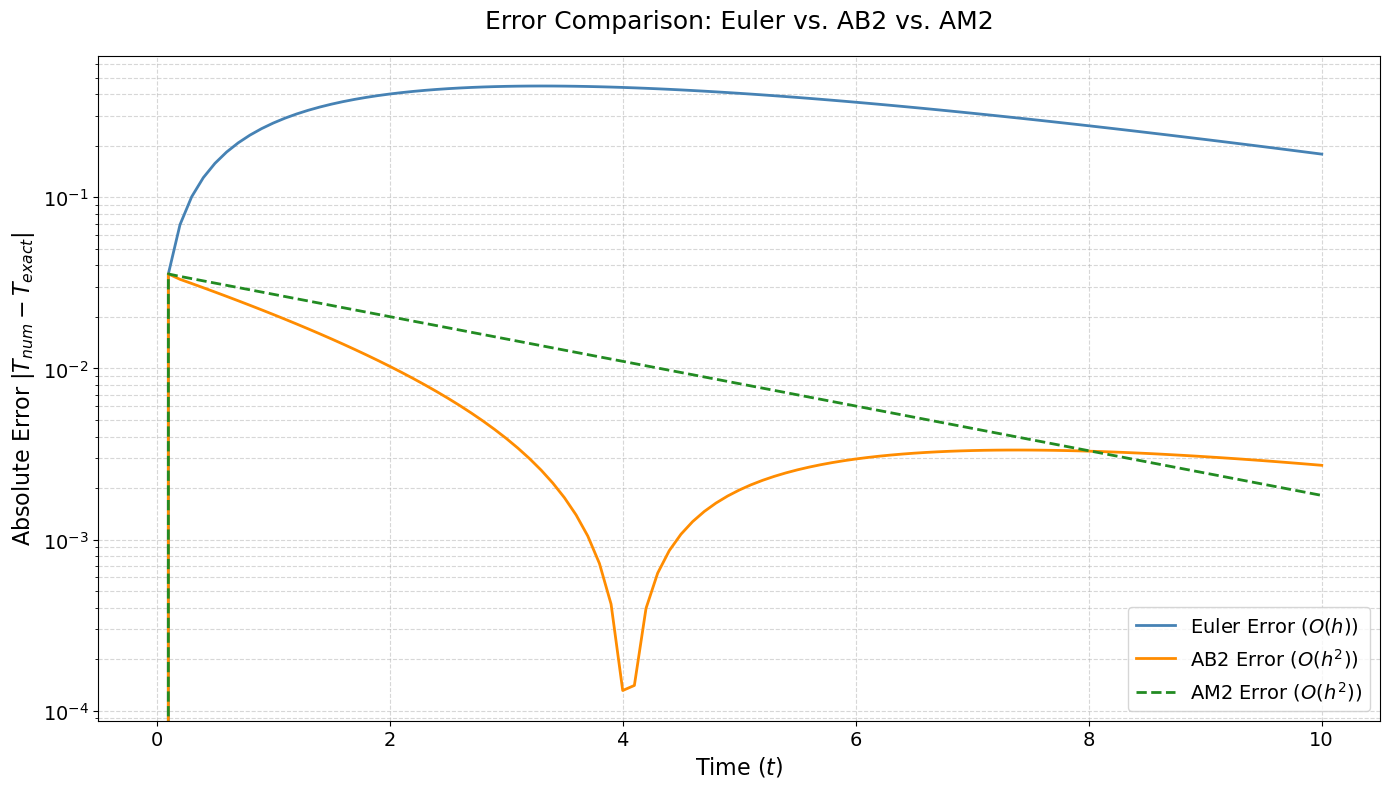

In [ ]:
h = 0.1

t, T_euler, T_exact, err_euler = solve_euler(h)
_, T_ab2, _, err_ab2 = solve_ab2(h)
_, T_am2, _, err_am2 = solve_am2(h)

plt.figure(figsize=(14, 8))


plt.plot(t, np.abs(T_euler - T_exact), label="Euler Error ($O(h)$)", color='steelblue', linewidth=2)
plt.plot(t, np.abs(T_ab2 - T_exact), label="AB2 Error ($O(h^2)$)", color='darkorange', linewidth=2)
plt.plot(t, np.abs(T_am2 - T_exact), label="AM2 Error ($O(h^2)$)", color='forestgreen', linewidth=2, linestyle='--')

plt.yscale("log")
plt.xlabel("Time ($t$)", fontsize=16)
plt.ylabel("Absolute Error $|T_{num} - T_{exact}|$", fontsize=16)
plt.title("Error Comparison: Euler vs. AB2 vs. AM2", fontsize=18, pad=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

In [36]:
def solve_bdf1(h, k=0.3, T_room=20, T0=100, t_end=10):
    t = np.arange(0, t_end + h, h)
    T = np.zeros(len(t))
    
    T[0] = T0
    
    for n in range(len(t) - 1):
        T[n + 1] = (T[n] + h * k * T_room) / (1 + h * k)
    
    T_exact = T_room + (T0 - T_room) * np.exp(-k * t)
    error = np.max(np.abs(T - T_exact))
    
    return t, T, T_exact, error

In [41]:
def solve_bdf2(h, k=0.3, T_room=20, T0=100, t_end=10):
    t = np.arange(0, t_end + h, h)
    T = np.zeros(len(t))
    T[0] = T0
    
    # Initial step using BDF1 to get T[1]
    T[1] = (T[0] + h * k * T_room) / (1 + h * k)
    
    # BDF2 loop
    for n in range(1, len(t) - 1):
        T[n + 1] = (4*T[n] - T[n-1] + 2*h*k*T_room) / (3 + 2*h*k)
    
    T_exact = T_room + (T0 - T_room) * np.exp(-k * t)
    max_error = np.max(np.abs(T - T_exact))
    return max_error

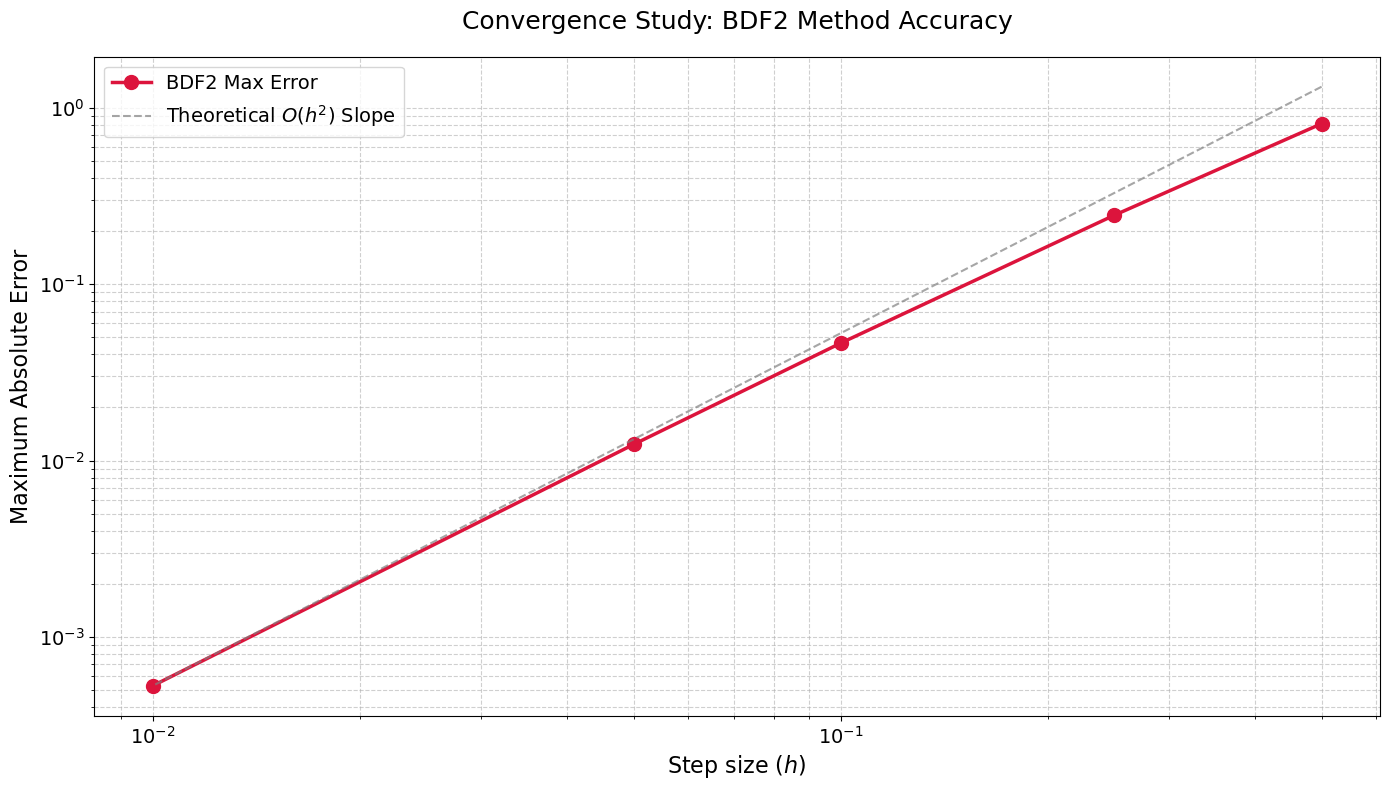

In [42]:
# analizing different step sizes to see the convergence behavior of the BDF2 method
hs = np.array([0.5, 0.25, 0.1, 0.05, 0.01])
errors = [solve_bdf2(h) for h in hs]

# convergence line
plt.figure(figsize=(14, 8))
plt.loglog(hs, errors, marker='o', markersize=10, linewidth=2.5, color='crimson', label="BDF2 Max Error")

# theoretical O(h^2) reference line
h_ref = np.array(hs)
error_ref = (errors[-1] / hs[-1]**2) * h_ref**2
plt.loglog(h_ref, error_ref, linestyle='--', color='gray', alpha=0.7, label="Theoretical $O(h^2)$ Slope")

plt.title("Convergence Study: BDF2 Method Accuracy", fontsize=18, pad=20)
plt.xlabel("Step size ($h$)", fontsize=16)
plt.ylabel("Maximum Absolute Error", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
def f(t, y):
    return -50 * (y - 0.2)

def exact_solution(t, y0=1.0, y_inf=0.2, lam=50):
    return y_inf + (y0 - y_inf) * np.exp(-lam * t)

def euler(h, T=1.0, y0=1.0):
    t = np.arange(0, T + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for n in range(len(t) - 1):
        y[n+1] = y[n] + h * f(t[n], y[n])

    return t, y

def ab2(h, T=1.0, y0=1.0):
    t = np.arange(0, T + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    # start with Euler
    y[1] = y[0] + h * f(t[0], y[0])

    for n in range(1, len(t) - 1):
        y[n+1] = y[n] + h/2 * (3*f(t[n], y[n]) - f(t[n-1], y[n-1]))

    return t, y

def am2(h, T=1.0, y0=1.0):
    t = np.arange(0, T + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    # start with Euler
    y[1] = y[0] + h * f(t[0], y[0])

    for n in range(1, len(t) - 1):

        fn = f(t[n], y[n])

        # implicit equation:
        # y_{n+1} = y_n + h/2 (fn + f(t_{n+1}, y_{n+1}))

        # since f is linear, we solve explicitly:
        y[n+1] = (y[n] + (h/2)*(fn + 1000*0.2)) / (1 + 25*h)

    return t, y

def bdf2(h, T=1.0, y0=1.0):
    t = np.arange(0, T + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    # start with BDF1 (implicit Euler)
    y[1] = (y[0] + h * 0.2 * 50) / (1 + h * 50)

    for n in range(1, len(t) - 1):
        y[n+1] = (4*y[n] - y[n-1] + 2*h*50*0.2) / (3 + 2*h*50)

    return t, y

def bdf2(h, T=1.0, y0=1.0):
    t = np.arange(0, T + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    # start with BDF1 (implicit Euler)
    y[1] = (y[0] + h * 0.2 * 50) / (1 + h * 50)

    for n in range(1, len(t) - 1):
        y[n+1] = (4*y[n] - y[n-1] + 2*h*50*0.2) / (3 + 2*h*50)

    return t, y




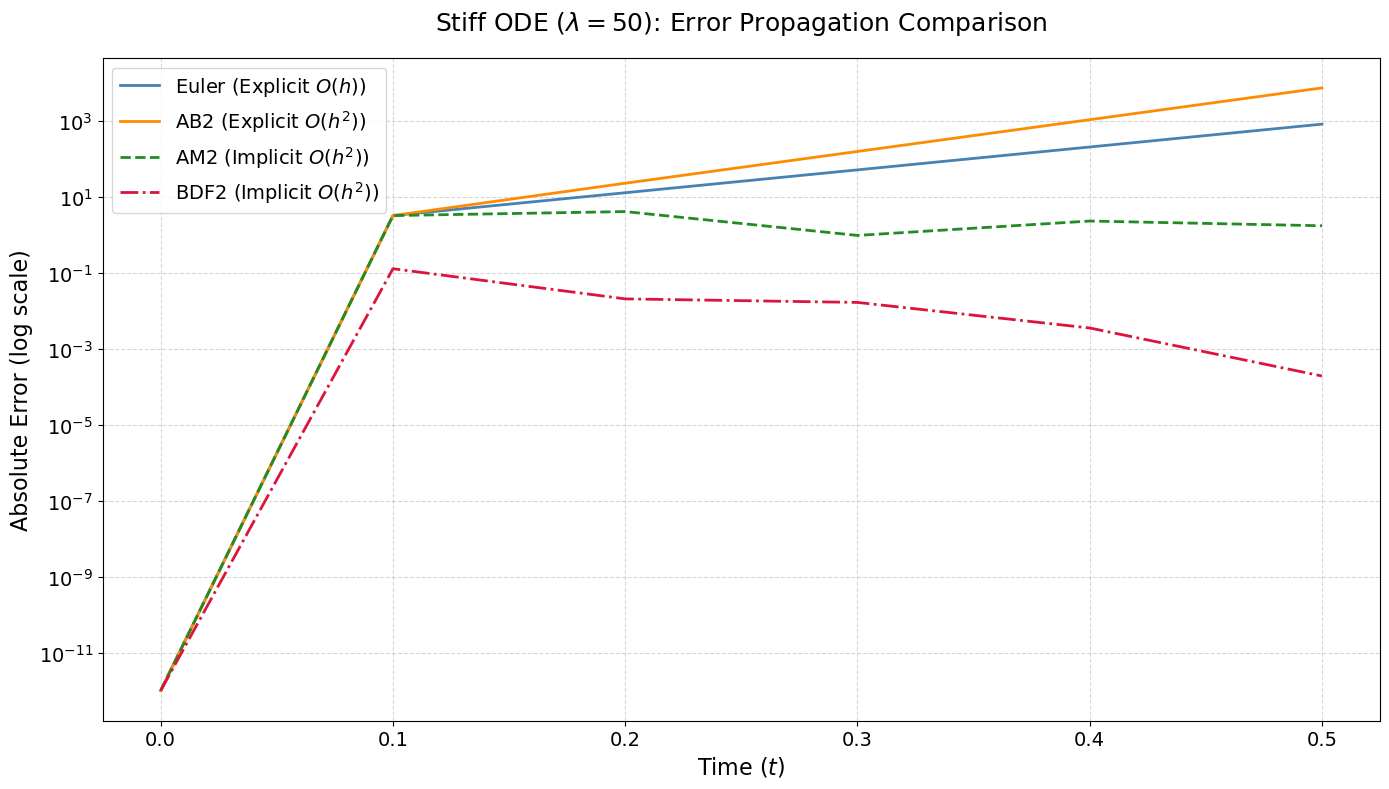

In [ ]:
# parameters
h = 0.1  # we chose a parameter close to the Euler stability limit (0.04)
T_final = 0.5
y0 = 1.0
eps = 1e-12

# solve using all methods
t_e, y_e = euler(h, T=T_final, y0=y0)
t_ab2, y_ab2 = ab2(h, T=T_final, y0=y0)
t_am2, y_am2 = am2(h, T=T_final, y0=y0)
t_bdf2, y_bdf2 = bdf2(h, T=T_final, y0=y0)

# exact solution for comparison
y_exact = exact_solution(t_e)

plt.figure(figsize=(14, 8))


plt.semilogy(t_e, np.abs(y_e - y_exact) + eps, label="Euler (Explicit $O(h)$)", color='steelblue', lw=2)
plt.semilogy(t_ab2, np.abs(y_ab2 - y_exact) + eps, label="AB2 (Explicit $O(h^2)$)", color='darkorange', lw=2)
plt.semilogy(t_am2, np.abs(y_am2 - y_exact) + eps, label="AM2 (Implicit $O(h^2)$)", color='forestgreen', lw=2, ls='--')
plt.semilogy(t_bdf2, np.abs(y_bdf2 - y_exact) + eps, label="BDF2 (Implicit $O(h^2)$)", color='crimson', lw=2, ls='-.')

plt.xlabel("Time ($t$)", fontsize=16)
plt.ylabel("Absolute Error (log scale)", fontsize=16)
plt.title("Stiff ODE ($\lambda=50$): Error Propagation Comparison", fontsize=18, pad=20)

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14, loc='best')

plt.tight_layout()
plt.show()

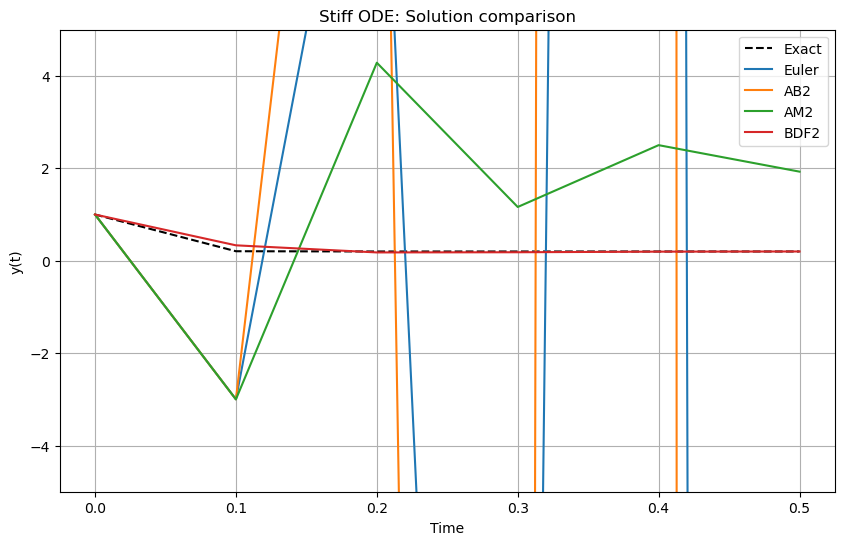

In [64]:
plt.figure(figsize=(10,6))

plt.plot(t_e, y_exact, 'k--', label="Exact")
plt.plot(t_e, y_e, label="Euler")
plt.plot(t_ab2, y_ab2, label="AB2")
plt.plot(t_am2, y_am2, label="AM2")
plt.plot(t_bdf2, y_bdf2, label="BDF2")

plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("Stiff ODE: Solution comparison")
plt.grid(True)
plt.ylim(-5, 5)  # we limit the y-axis to better visualize the differences
plt.legend()
plt.show()